In [12]:
pip install transformers datasets huggingface_hub


Note: you may need to restart the kernel to use updated packages.


Found 3781 files belonging to 3 classes.
Using 3403 files for training.
Found 3781 files belonging to 3 classes.
Using 378 files for validation.
Classes: ['Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


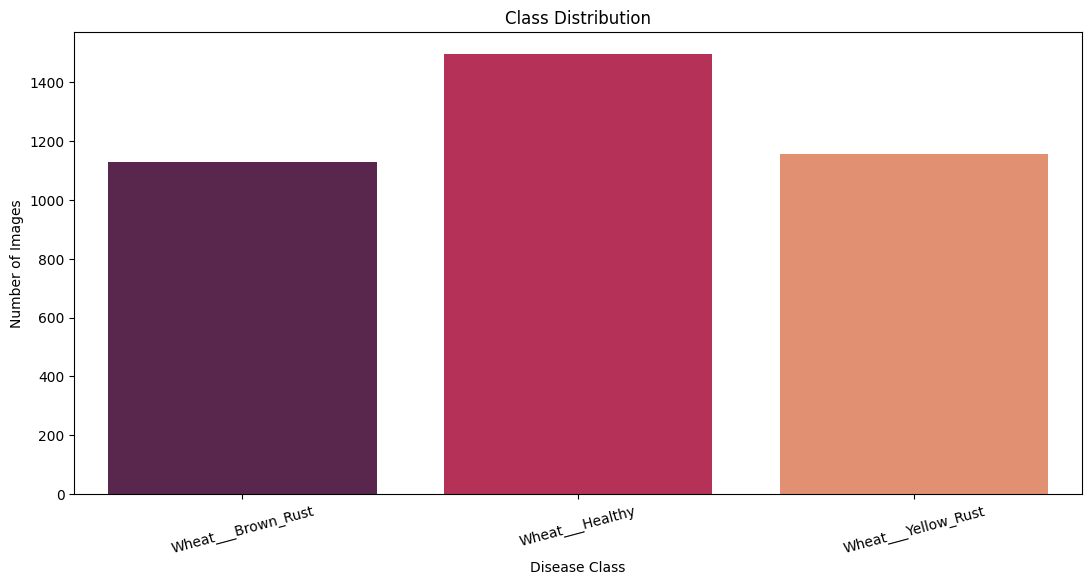


Class Weights:
Wheat___Brown_Rust: 1.12
Wheat___Healthy: 0.84
Wheat___Yellow_Rust: 1.09


In [13]:
# ----------------------- #
# 1. Install Dependencies
# ----------------------- #
!pip install transformers datasets huggingface_hub -q

# ----------------------- #
# 2. Imports
# ----------------------- #
import os
import glob as gb
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from transformers import (
    TFDeiTForImageClassification,
    AutoImageProcessor
)

# ----------------------- #
# 3. Constants & Dataset
# ----------------------- #
IMG_SIZE = (160, 160)
BATCH_SIZE = 8
EPOCHS = 10
SEED = 42

directory = "/kaggle/input/wheat-leaf-diseases/Wheat Leaf Diseases Dataset From Bangladesh"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='training',
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.1,
    subset='validation',
    seed=SEED
)

class_names = train_dataset.class_names
print("Classes:", class_names)

# ----------------------- #
# 4. Class Distribution
# ----------------------- #
data_imbalance = []
for class_folder in class_names:
    file_list = gb.glob(os.path.join(directory, class_folder, '*.*'))
    data_imbalance.append(len(file_list))

plt.figure(figsize=(13, 6))
sns.barplot(x=class_names, y=data_imbalance, palette="rocket")
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Disease Class")
plt.xticks(rotation=15)
plt.show()

# ----------------------- #
# 5. Class Weights
# ----------------------- #
total_images = sum(data_imbalance)
class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}
print("\nClass Weights:")
for i, w in class_weight.items():
    print(f"{class_names[i]}: {w:.2f}")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Patch Embedding (Conv based)
def conv_embedding(x, filters, kernel_size=3, strides=1, name="conv_embed"):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same', name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("gelu", name=f"{name}_gelu")(x)
    return x

# Cross-Shaped Window Attention Layer
class CrossShapedWindowAttention(layers.Layer):
    def __init__(self, dim, num_heads, dropout=0.0, name_prefix="cswin"):
        super().__init__(name=name_prefix)
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = layers.Dense(dim * 3, name=f"{name_prefix}_qkv")
        self.proj = layers.Dense(dim, name=f"{name_prefix}_proj")
        self.dropout = layers.Dropout(dropout)

    def call(self, x):
        B, H, W, C = tf.shape(x)[0], x.shape[1], x.shape[2], x.shape[3]
        qkv = self.qkv(x)  # (B, H, W, 3C)
        qkv = tf.reshape(qkv, [B, H * W, 3, self.num_heads, C // self.num_heads])
        qkv = tf.transpose(qkv, perm=[2, 0, 3, 1, 4])  # (3, B, heads, HW, dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.dropout(attn)
        out = tf.matmul(attn, v)  # (B, heads, HW, dim)
        out = tf.transpose(out, perm=[0, 2, 1, 3])
        out = tf.reshape(out, [B, H, W, C])
        out = self.proj(out)
        return out

# Transformer Block
def cswin_block(x, num_heads, projection_dim, dropout=0.1, name="cswin_block"):
    x1 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    attn = CrossShapedWindowAttention(projection_dim, num_heads, dropout, name_prefix=f"{name}_attn")(x1)
    x2 = layers.Add(name=f"{name}_add1")([x, attn])
    
    x3 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x2)
    x4 = layers.Dense(projection_dim * 4, activation="gelu", name=f"{name}_dense1")(x3)
    x4 = layers.Dense(projection_dim, name=f"{name}_dense2")(x4)
    
    return layers.Add(name=f"{name}_add2")([x2, x4])

# Stage with multiple Transformer Blocks
def cswin_stage(x, depth, projection_dim, num_heads, name="cswin_stage"):
    for i in range(depth):
        x = cswin_block(x, num_heads, projection_dim, name=f"{name}_block{i}")
    return x

# Final CSWin-B Model
def create_cswin_b_model(input_shape=(160, 160, 3), num_classes=3):
    inputs = keras.Input(shape=input_shape, name="input")

    # Stage 1
    x = conv_embedding(inputs, filters=64, strides=2, name="stage1_embed")
    x = cswin_stage(x, depth=2, projection_dim=64, num_heads=2, name="stage1")

    # Stage 2
    x = conv_embedding(x, filters=128, strides=2, name="stage2_embed")
    x = cswin_stage(x, depth=2, projection_dim=128, num_heads=4, name="stage2")

    # Stage 3
    x = conv_embedding(x, filters=256, strides=2, name="stage3_embed")
    x = cswin_stage(x, depth=4, projection_dim=256, num_heads=8, name="stage3")

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    return keras.Model(inputs, outputs, name="CSWin-B")


In [14]:
model = create_cswin_b_model(input_shape=(160, 160, 3), num_classes=num_classes)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=2)
    ]
)


Model: "CSWin-B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)        │ (None, 160, 160, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_conv         │ (None, 80, 80, 64)     │          1,792 │ input[0][0]            │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_bn           │ (None, 80, 80, 64)     │            256 │ stage1_embed_conv[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_gelu         │ (None, 80, 80, 64)     │              0 │ stage1_embed_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_ln1         │ (None, 80, 80, 64)     │            128 │ stage1_embed_gelu[0][… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_attn        │ (None, 80, 80, 64)     │         16,640 │ stage1_block0_ln1[0][… │
│ (CrossShapedWindowAttent… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_add1 (Add)  │ (None, 80, 80, 64)     │              0 │ stage1_embed_gelu[0][… │
│                           │                        │                │ stage1_block0_attn[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_ln2         │ (None, 80, 80, 64)     │            128 │ stage1_block0_add1[0]… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_dense1      │ (None, 80, 80, 256)    │         16,640 │ stage1_block0_ln2[0][… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_dense2      │ (None, 80, 80, 64)     │         16,448 │ stage1_block0_dense1[… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block0_add2 (Add)  │ (None, 80, 80, 64)     │              0 │ stage1_block0_add1[0]… │
│                           │                        │                │ stage1_block0_dense2[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block1_ln1         │ (None, 80, 80, 64)     │            128 │ stage1_block0_add2[0]… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block1_attn        │ (None, 80, 80, 64)     │         16,640 │ stage1_block1_ln1[0][… │
│ (CrossShapedWindowAttent… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_block1_add1 (A

 Total params: 4,028,931 (15.37 MB)

 Trainable params: 4,028,035 (15.37 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 244s 457ms/step - accuracy: 0.7489 - loss: 1.0264 - val_accuracy: 0.8201 - val_loss: 0.8319 - learning_rate: 1.0000e-04
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 173s 406ms/step - accuracy: 0.8532 - loss: 0.5905 - val_accuracy: 0.9630 - val_loss: 0.0789 - learning_rate: 1.0000e-04
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 173s 406ms/step - accuracy: 0.8886 - loss: 0.3842 - val_accuracy: 0.9709 - val_loss: 0.0762 - learning_rate: 1.0000e-04
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 173s 406ms/step - accuracy: 0.9278 - loss: 0.2550 - val_accuracy: 0.9471 - val_loss: 0.1456 - learning_rate: 1.0000e-04
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 173s 406ms/step - accuracy: 0.9384 - loss: 0.2121 - val_accuracy: 0.9656 - val_loss: 0.0934 - learning_rate: 1.0000e-04
Epoch 6/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 173s 406ms/step - accuracy: 0.9502 - loss: 0.1306 - val_accuracy: 0.9921 - val_loss: 0.0139 - learning_rate: 1.0000e-05
Epoch 7/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
test_loss, test_acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {test_acc:.2f}")


48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.9973 - loss: 0.0089
Validation Accuracy: 0.99


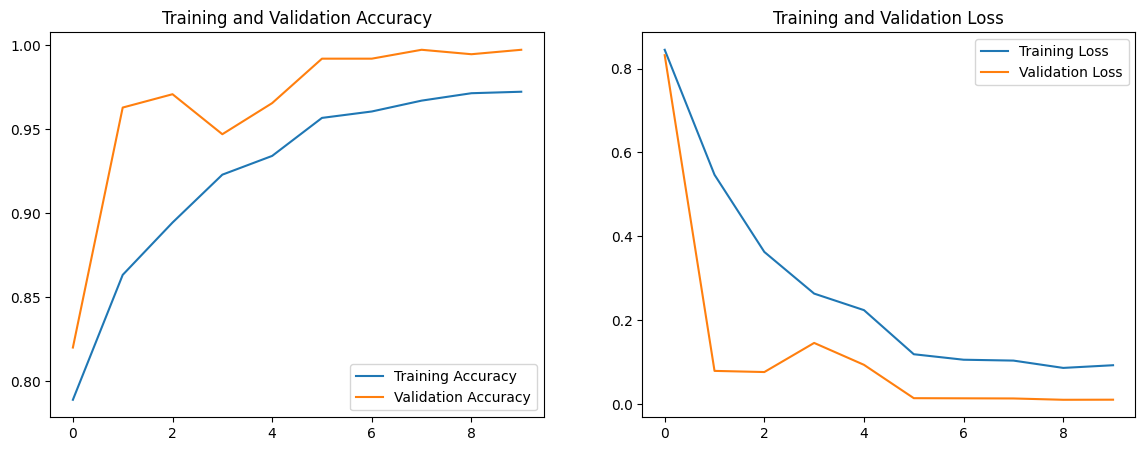

In [16]:
def plot_training(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.show()

plot_training(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━

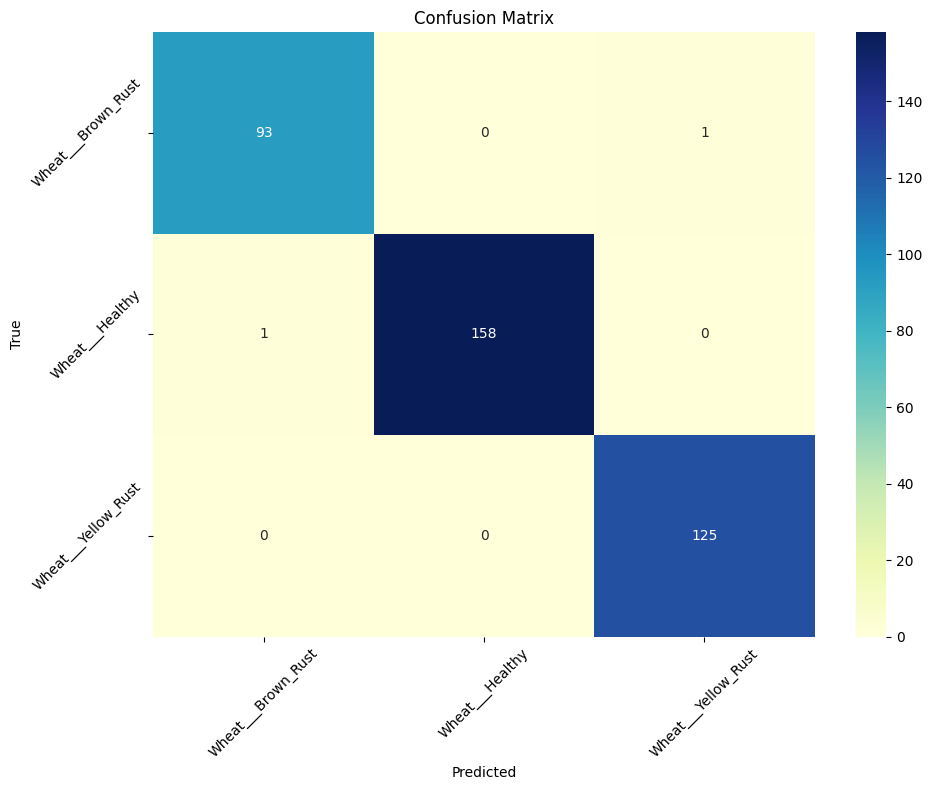


Classification Report:

                     precision    recall  f1-score   support

 Wheat___Brown_Rust       0.99      0.99      0.99        94
    Wheat___Healthy       1.00      0.99      1.00       159
Wheat___Yellow_Rust       0.99      1.00      1.00       125

           accuracy                           0.99       378
          macro avg       0.99      0.99      0.99       378
       weighted avg       0.99      0.99      0.99       378



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Get predictions
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
